## Art classifier(미술 사조 다중 클래스 분류모델)

In [2]:
# !pip install tensorflow
!pip install shutil
!pip install traceback
!pip install mlflow

ERROR: Could not find a version that satisfies the requirement shutil (from versions: none)
ERROR: No matching distribution found for shutil
ERROR: Could not find a version that satisfies the requirement traceback (from versions: none)
ERROR: No matching distribution found for traceback


In [77]:
# from google.colab import drive

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import PIL
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import pathlib  # 객체지향 방식으로 파일 경로를 다룸 (경로 라이브러리)
from pathlib import Path
import gc
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import shutil
import traceback
import mlflow
import urllib.request

1. 데이터 불러오기

In [ ]:
drive.mount('/content/drive')

In [4]:
# Google colab용
# data_dir = pathlib.Path("/content/drive/MyDrive/project_deepLearning/code/deepLearning01/dataset/WikiArt_Art_Movements_or_Styles")
# data_dir = pathlib.Path("/content/drive/MyDrive/project_deepLearning/code/deepLearning01/dataset/WikiArt_Art_Movements_or_Styles(1000)")

# kaggle용
data_dir = pathlib.Path("/kaggle/input/datasets/sivarazadi/wikiart-art-movementsstyles")

0. 폰트 지정

In [5]:
# 코랩이 인식 가능한 나눔 글꼴 설치 및 폰트 캐시 삭제
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 1. 설치된 나눔바른고딕 폰트 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)

# 2. Matplotlib의 기본 폰트를 'NanumBarunGothic'으로 설정
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 141 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (44.3 MB/s)    
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
Selecting previously unselected package fonts-nanum.
(Reading database ... 125128 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers

In [10]:
# 전체 클래스 확인 (가장 상위 폴더 이름 기준)
classes = sorted([item.name for item in data_dir.glob('*/') if item.is_dir()])

# 1. 찾고자 하는 확장자 리스트 정의
extensions = ['*.jpg', '*.jpeg', '*.png', '*.gif']
image_paths = []

# 2. rglob()을 사용하여 모든 하위 디렉터리에서 이미지를 찾아 리스트에 추가 (extend)
for ext in extensions:
    image_paths.extend(data_dir.rglob(ext))

# 3. 전체 이미지 갯수 계산
image_count = len(image_paths)

print(f"전체 클래스: {classes}")
print(f"전체 이미지 개수: {image_count}")

전체 클래스: ['Academic_Art', 'Art_Nouveau', 'Baroque', 'Expressionism', 'Japanese_Art', 'Neoclassicism', 'Primitivism', 'Realism', 'Renaissance', 'Rococo', 'Romanticism', 'Symbolism', 'Western_Medieval']
전체 이미지 개수: 42500


In [11]:
# 각 클래스별 이미지 개수 확인
class_images_count = {}
extensions = ['*.jpg', '*.jpeg', '*.png', '*.gif'] # 찾을 이미지 확장자

for class_name in classes:
    class_dir = data_dir / class_name # 특정 클래스의 폴더 경로
    class_count = 0
    
    # 해당 클래스 폴더 내의 모든 하위 폴더를 탐색하며 이미지 개수 합산
    for ext in extensions:
        class_count += len(list(class_dir.rglob(ext)))
        
    class_images_count[class_name] = class_count  # 딕셔너리에 저장
    print(f"{class_name}: {class_count}개 이미지")

Academic_Art: 1305개 이미지
Art_Nouveau: 3035개 이미지
Baroque: 5312개 이미지
Expressionism: 2607개 이미지
Japanese_Art: 2235개 이미지
Neoclassicism: 3115개 이미지
Primitivism: 1324개 이미지
Realism: 5373개 이미지
Renaissance: 6192개 이미지
Rococo: 2521개 이미지
Romanticism: 6813개 이미지
Symbolism: 1510개 이미지
Western_Medieval: 1158개 이미지


/tmp/ipykernel_58/879732306.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(class_names)) # 'tab20' colormap 사용, 클래스 수에 맞춰 색상 생성


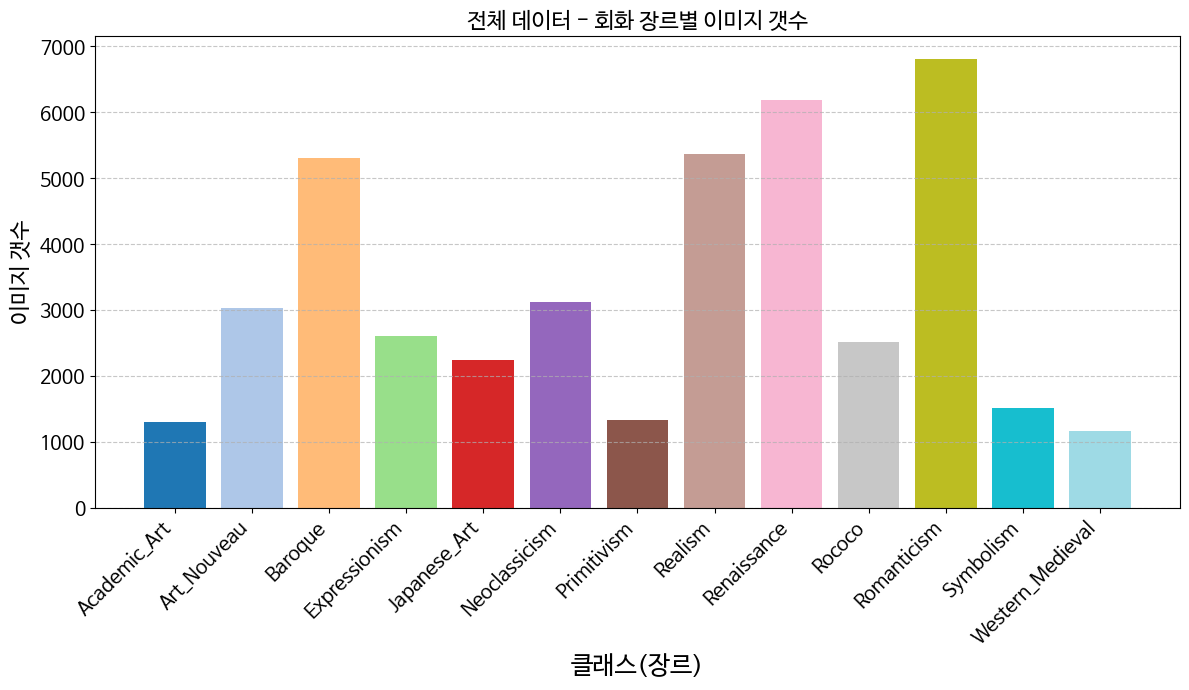

In [12]:
# 전체 클래스별 이미지 분포 (막대 차트)
plt.figure(figsize=(12, 7))

# 클래스 이름과 이미지 갯수 추출
class_names = list(class_images_count.keys())
counts = list(class_images_count.values())

# 각 클래스에 고유한 색상 할당
colors = plt.cm.get_cmap('tab20', len(class_names)) # 'tab20' colormap 사용, 클래스 수에 맞춰 색상 생성

plt.bar(class_names, counts, color=[colors(i) for i in range(len(class_names))])

plt.xlabel('클래스(장르)', fontsize=18)
plt.ylabel('이미지 갯수', fontsize=16)
plt.title('전체 데이터 - 회화 장르별 이미지 갯수', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

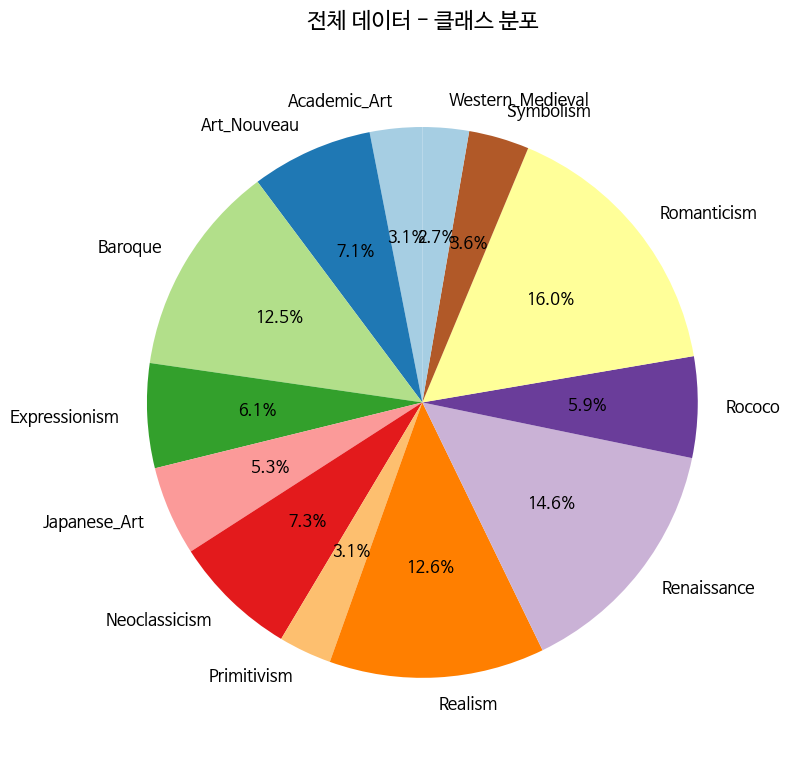

In [9]:
# 전체 클래스별 이미지 분포 (파이 차트)
plt.figure(figsize=(8, 8))

# 클래스 이름과 이미지 갯수 추출
class_names_for_pie = list(class_images_count.keys())
counts_for_pie = list(class_images_count.values())

# 0개인 클래스는 제외하고 시각화 (파이차트에서 0은 의미 없음)
filtered_class_names = [name for name, count in zip(class_names_for_pie, counts_for_pie) if count > 0]
filtered_counts = [count for count in counts_for_pie if count > 0]

plt.pie(filtered_counts, labels=filtered_class_names, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors, textprops={'fontsize': 12})
plt.title('전체 데이터 - 클래스 분포', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

2. EDA 및 데이터 전처리

# 데이터셋 설정

In [13]:
# 모델에 사용할 장르(클래스) 선택
SEED = 123
SELECTED_CLASSES = [
    "Art_Nouveau",
    "Baroque",
    "Japanese_Art",
    "Realism",
    "Western_Medieval"
]

# SELECTED_CLASSES(선택한 장르) 안에서 images_per_class(장르당 이미지 갯수)만큼의 샘플 추출
class_names = SELECTED_CLASSES
num_classes = len(class_names)
class_to_index = {name: i for i, name in enumerate(class_names)}

# 3. 모델에 사용할/사용하지 않을 이미지 개수 계산
images_per_class = 200  # 사용할 이미지의 갯수
unused_images_per_class = []  # 사용하지 않고 남은 이미지 개수 (나중에 그래프 그릴 때 사용)
split_summary = []            # 요약 결과를 담을 리스트

# 선택된 클래스(class_names)만 반복문을 돌면서 계산합니다.
for class_name in class_names:
    # 위에서 딕셔너리로 저장했으므로, 이제 에러 없이 문자열로 값을 찾을 수 있습니다.
    class_count = class_images_count[class_name]

    # 실제 사용될 이미지 수 (혹시 전체 이미지가 200개보다 적을 경우를 대비해 안전하게 계산)
    used_count = min(images_per_class, class_count)

    # 남은 이미지 개수 계산
    unused_count = class_count - used_count

    # 리스트에 남은 개수(숫자 1개)를 추가
    unused_images_per_class.append(unused_count)

    # split_summary에는 해당 장르의 이름, 사용된 개수, 남은 개수를 하나의 세트로 묶어서 추가
    split_summary.append((class_name, used_count, unused_count))

In [14]:
# 설정 결과 출력
print("=== 데이터셋 설정 결과 ===")
print("선택한 장르:", class_names)
print(f"장르당 {images_per_class}개의 이미지를 사용합니다.")
print(f"장르당 {unused_images_per_class}개의 이미지를 제외합니다.")

print("\n=== 데이터 분할 요약 ===")
for summary in split_summary:
    print(f"클래스: {summary[0]:<17} | 사용: {summary[1]}개 | 남음: {summary[2]}개")

=== 데이터셋 설정 결과 ===
선택한 장르: ['Art_Nouveau', 'Baroque', 'Japanese_Art', 'Realism', 'Western_Medieval']
장르당 200개의 이미지를 사용합니다.
장르당 [2835, 5112, 2035, 5173, 958]개의 이미지를 제외합니다.

=== 데이터 분할 요약 ===
클래스: Art_Nouveau       | 사용: 200개 | 남음: 2835개
클래스: Baroque           | 사용: 200개 | 남음: 5112개
클래스: Japanese_Art      | 사용: 200개 | 남음: 2035개
클래스: Realism           | 사용: 200개 | 남음: 5173개
클래스: Western_Medieval  | 사용: 200개 | 남음: 958개


In [15]:
# rng = np.random.default_rng(SEED)

# for class_name in class_names:
#     class_dir = data_dir / class_name
#     for ext in extensions:
#       image_paths = sorted(class_dir.glob(ext))

#     if not image_paths:
#         raise FileNotFoundError(f"No images found: {class_dir}")

#     rng.shuffle(image_paths)
#     selected_paths = image_paths[:min(images_per_class, len(image_paths))]

#     val_count = int(len(selected_paths) * VALIDATION_SPLIT)
#     val_count = max(1, val_count)

#     val_class_paths = selected_paths[:val_count]
#     train_class_paths = selected_paths[val_count:]
#     label = class_to_index[class_name]

#     train_paths.extend([str(path) for path in train_class_paths])
#     train_labels.extend([label] * len(train_class_paths))
#     val_paths.extend([str(path) for path in val_class_paths])
#     val_labels.extend([label] * len(val_class_paths))

#     split_summary.append((class_name, len(train_class_paths), len(val_class_paths)))

# print("선택한 장르:", class_names)
# print(f"장르당 {images_per_class}개의 이미지를 사용합니다.")
# for class_name, train_count, val_count in split_summary:
#     print(f"{class_name}: train {train_count}, val {val_count}")
# print(f"전체 사용 이미지 갯수: 총 {len(train_paths)+len(val_paths)}개, train {len(train_paths)}개, validation {len(val_paths)}개")

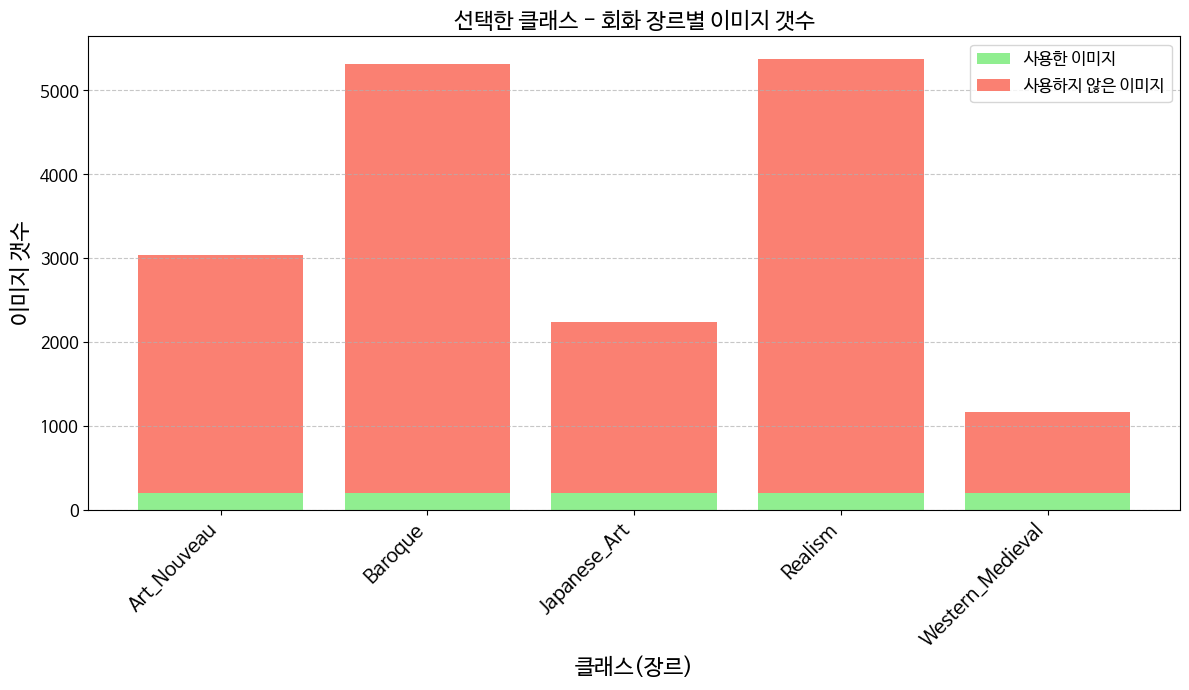

In [16]:
# split_summary에서 데이터 추출
plot_class_names = [item[0] for item in split_summary] # 클래스 이름
plot_used_counts = [item[1] for item in split_summary]   # 사용된 이미지 수
plot_unused_counts = [item[2] for item in split_summary] # 사용되지 않은 이미지 수

# 누적 분포 히스토그램 그리기 (Stacked Bar Chart)
plt.figure(figsize=(12, 7))

# 'used_counts'를 먼저 그리고 그 위에 'unused_counts'를 쌓습니다.
plt.bar(plot_class_names, plot_used_counts, label='사용한 이미지', color='lightgreen')
plt.bar(plot_class_names, plot_unused_counts, bottom=plot_used_counts, label='사용하지 않은 이미지', color='salmon')

plt.xlabel('클래스(장르)', fontsize=16)
plt.ylabel('이미지 갯수', fontsize=16)
plt.title('선택한 클래스 - 회화 장르별 이미지 갯수', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#훈련 및 검증 데이터셋 생성

In [17]:
# 학습 데이터 설정
VALIDATION_SPLIT = 0.2
img_height = 224
img_width = 224
batch_size = 32
epochs = 10

In [18]:
# train 데이터 확인
print(f"Train 클래스: {class_names}")
print(f"Train 클래스 갯수: {num_classes}")
print(f"클래스 인덱스: {class_to_index}")

Train 클래스: ['Art_Nouveau', 'Baroque', 'Japanese_Art', 'Realism', 'Western_Medieval']
Train 클래스 갯수: 5
클래스 인덱스: {'Art_Nouveau': 0, 'Baroque': 1, 'Japanese_Art': 2, 'Realism': 3, 'Western_Medieval': 4}


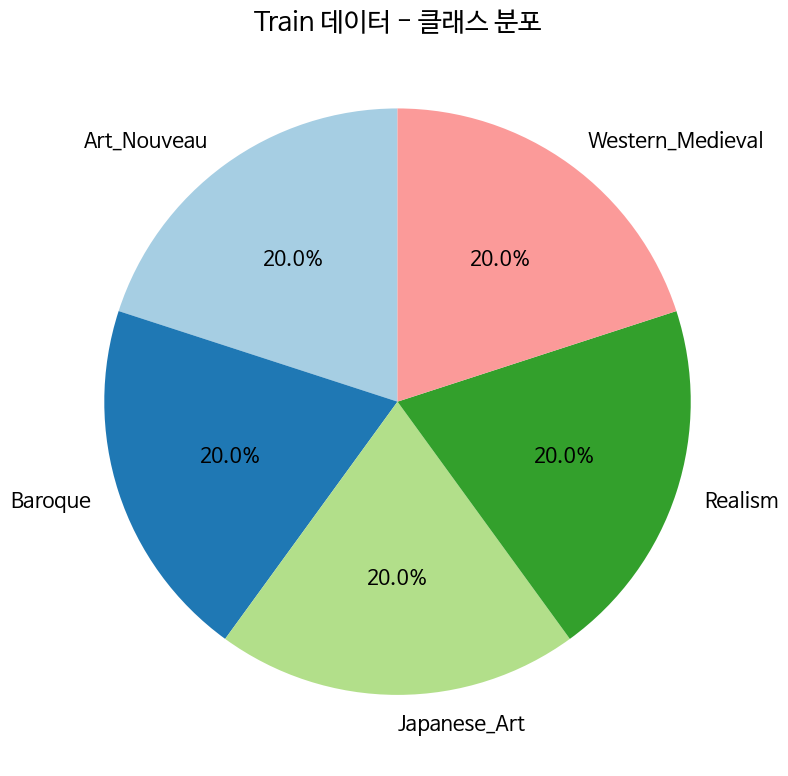

In [19]:
# 학습 이미지 비율 파이차트
plt.figure(figsize=(8, 8))
plt.pie(plot_used_counts, labels=plot_class_names, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors, textprops={'fontsize': 15})
plt.title('Train 데이터 - 클래스 분포', fontsize=19)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

In [21]:
# 데이터셋 생성
train_paths, train_labels = [], []
val_paths, val_labels = [], []
split_summary = []

rng = np.random.default_rng(SEED)

for class_name in class_names:
    # class_dir = data_dir / class_name
    class_dir = data_dir / class_name / class_name
    image_paths = sorted(class_dir.glob("*.jpg"))

    if not image_paths:
        raise FileNotFoundError(f"No images found: {class_dir}")

    rng.shuffle(image_paths)
    selected_paths = image_paths[:min(images_per_class, len(image_paths))]

    val_count = int(len(selected_paths) * VALIDATION_SPLIT)
    val_count = max(1, val_count)

    val_class_paths = selected_paths[:val_count]
    train_class_paths = selected_paths[val_count:]
    label = class_to_index[class_name]

    train_paths.extend([str(path) for path in train_class_paths])
    train_labels.extend([label] * len(train_class_paths))
    val_paths.extend([str(path) for path in val_class_paths])
    val_labels.extend([label] * len(val_class_paths))

    split_summary.append((class_name, len(train_class_paths), len(val_class_paths)))

print("선택한 장르:", class_names)
print(f"장르당 {images_per_class}개의 이미지를 사용합니다.")
for class_name, train_count, val_count in split_summary:
    print(f"{class_name}: train {train_count}, val {val_count}")
print(f"전체 사용 이미지 갯수: 총 {len(train_paths)+len(val_paths)}개, train {len(train_paths)}개, validation {len(val_paths)}개")

선택한 장르: ['Art_Nouveau', 'Baroque', 'Japanese_Art', 'Realism', 'Western_Medieval']
장르당 200개의 이미지를 사용합니다.
Art_Nouveau: train 160, val 40
Baroque: train 160, val 40
Japanese_Art: train 160, val 40
Realism: train 160, val 40
Western_Medieval: train 160, val 40
전체 사용 이미지 갯수: 총 1000개, train 800개, validation 200개


#데이터셋 성능 최적화

In [22]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [img_height, img_width])
    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_ds = (
    train_ds
    .shuffle(len(train_paths), seed=SEED, reshuffle_each_iteration=True)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

I0000 00:00:1782800079.835455      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782800079.838220      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


#데이터 증강 레이어 생성 (다양한 각도의 이미지 학습)

In [23]:
def make_data_augmentation():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),  # 좌우 반전 (미술품의 좌우가 바뀌어도 장르는 유지됨)
        layers.RandomRotation(0.06),       # 미세한 회전 (최대 6도)
        layers.RandomZoom(0.12),           # 미세한 확대/축소
        layers.RandomTranslation(0.05, 0.05),  # 변형
        layers.RandomContrast(0.12),  # 대조
    ], name="data_augmentation")

data_augmentation = make_data_augmentation()

# 회화 장르 분류에서는 너무 과한 증강은 오히려 독(그림의 구도와 색감 자체가 장르 단서) => vertical flip, 큰 회전, 과한 색상 변화, 과한 crop은 피하는 게 좋아요.
# 모델 설계 시 맨 앞에 삽입

#샘플 이미지 출력

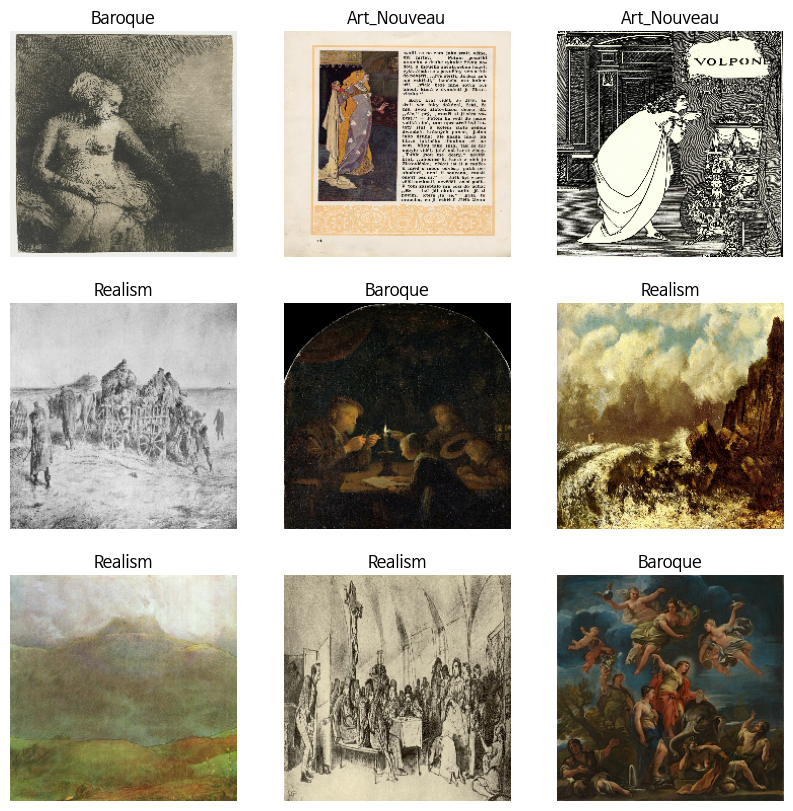

In [24]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):  #첫 번째 배치를 가져옴
    for i in range(9):
        plt.subplot(3, 3, i+1)  #행, 열, 순번(1부터 시작)
        plt.imshow(images[i].numpy().astype("uint8"))   #astype("uint8"): 픽셀값을 0~255 정수로 변환 => 이미지를 화면에 출력 가능한 데이터 형식으로
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

3. 모델 생성 (사용자 정의 CNN 모델, EfficientNetB0, ResNet-50)

3-1. 모델 생성

In [27]:
# 커스텀 CNN 모델
def cnn_model():
    model = models.Sequential([
        layers.Input(shape=(img_height, img_width, 3)),  #입력 이미지 크기 지정
        make_data_augmentation(),  #데이터 증강 레이어
        layers.Rescaling(1./255),  #정규화(Normalization)
        layers.Conv2D(16, 3, padding='same', activation='relu'),  #padding='same: 주위를 0으로 채움
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.4),  # 뉴런 제거: 데이터가 적을 때는 Dropout 비율을 0.3~0.4로 높이면 과적합 방지에 좋습니다.
        layers.Flatten(),
        layers.Dense(128, activation='relu'),  #뉴런의 갯수
        layers.Dense(num_classes, activation='softmax')  #마지막 출력층  #(클래스 갯수, 필터링 함수)
    ])

    return model


# EfficientNetB0 모델
def efficientNetB0_model():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_height, img_width, 3)
    )

    base_model.trainable = False  #base model freeze

    model = models.Sequential([
        layers.Input(shape=(img_height, img_width, 3)),  #input 데이터 형식 지정
        make_data_augmentation(),  #데이터 증강 레이어
        base_model,  #EfficientNetB0 base_model
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


# ResNet-50 모델
def resNet50_model():
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(img_height, img_width, 3)
    )

    base_model.trainable = False  #base model freeze

    model = models.Sequential([
        layers.Input(shape=(img_height, img_width, 3)),
        make_data_augmentation(),
        layers.Lambda(tf.keras.applications.resnet50.preprocess_input),  #ResNet50 전처리
        base_model,  #ResNet50 base_model
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


# 모델 생성 함수 딕셔너리
# 모델 객체를 한 번에 만들면 메모리를 많이 쓰므로, 학습할 때 하나씩 생성합니다.
model_group = {
    "CNN": cnn_model,
    "EfficientNetB0": efficientNetB0_model,
    "ResNet50": resNet50_model
}


##### 모델 생성 순서 #####
# Input
# → 데이터 증강(data_augmentation)
# → EfficientNetB0
# → GlobalAveragePooling
# → Dropout
# → Dense softmax

In [28]:
# 모델 컴파일 함수
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

3-2. 귀환 지점 설정

In [29]:
if not os.path.exists('model'):
    os.makedirs('model')

In [30]:
# 모델별 콜백 생성(ModelCheckpoint, EarlyStopping을 함께 생성)
os.makedirs('./model', exist_ok=True)

def make_callbacks(model_name):
    return [
        ModelCheckpoint(
            filepath=f'./model/{model_name}_best.keras',
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]

4. 모델 학습

4-1. 모델 학습

In [31]:
# 학습 기록과 검증 지표 저장
history_group = {}
eval_group = {}

# 학습할 모델의 목록
models_to_train = ["CNN", "EfficientNetB0", "ResNet50"]
# models_to_train = ["EfficientNetB0"]

In [32]:
for name in models_to_train:
    tf.keras.backend.clear_session()
    print(f"\nTraining {name} model...")

    model = compile_model(model_group[name]())
    history_group[name] = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=make_callbacks(name)
    )

    loss, accuracy = model.evaluate(val_ds, verbose=0)
    eval_group[name] = {"loss": loss, "accuracy": accuracy}
    print(f"{name} 검증 정확도: {accuracy:.4f}")

    model.save(f"./model/{name}_last.keras")
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Training CNN model...
Epoch 1/10


E0000 00:00:1782800123.949388      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1782800127.114472     285 cuda_dnn.cc:529] Loaded cuDNN version 91002


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.2005 - loss: 2.2219
Epoch 1: val_loss improved from None to 1.57791, saving model to ./model/CNN_best.keras

Epoch 1: finished saving model to ./model/CNN_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 469ms/step - accuracy: 0.2125 - loss: 1.8397 - val_accuracy: 0.2400 - val_loss: 1.5779
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.2710 - loss: 1.5664
Epoch 2: val_loss improved from 1.57791 to 1.44778, saving model to ./model/CNN_best.keras

Epoch 2: finished saving model to ./model/CNN_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 360ms/step - accuracy: 0.3100 - loss: 1.5424 - val_accuracy: 0.4000 - val_loss: 1.4478
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.3890 - loss: 1.4413
Epoch 3: val_loss improved from 1.44778 to 1.37949, saving model to ./model/CNN_best.keras

Epoch 3: finished saving model to ./model/CNN_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 359ms/step - accuracy: 0.3762 - loss: 1.4368

E0000 00:00:1782800237.854022      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.2794 - loss: 1.6114
Epoch 1: val_loss improved from None to 1.15749, saving model to ./model/EfficientNetB0_best.keras

Epoch 1: finished saving model to ./model/EfficientNetB0_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 514ms/step - accuracy: 0.3713 - loss: 1.4827 - val_accuracy: 0.5500 - val_loss: 1.1575
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.6303 - loss: 1.0710
Epoch 2: val_loss improved from 1.15749 to 0.96444, saving model to ./model/EfficientNetB0_best.keras

Epoch 2: finished saving model to ./model/EfficientNetB0_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 407ms/step - accuracy: 0.6400 - loss: 1.0363 - val_accuracy: 0.6450 - val_loss: 0.9644
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6880 - loss: 0.8979
Epoch 3: val_loss improved from 0.96444 to 0.90000, saving model to ./model/EfficientNetB0_best.keras

Epoch 3: finished saving model to ./model/EfficientNetB0_best.keras
25/25 ━

4-2. 학습 결과 및 성능 비교 (model evaluate)

In [33]:
# 성능 지표 (loss, accuracy)
if not eval_group:
    print("평가 결과가 없습니다. 먼저 모델 학습을 실행하세요.")
else:
    for name, metrics in eval_group.items():
        print(f"{name} val_loss: {metrics['loss']:.4f}, val_accuracy: {metrics['accuracy']:.4f}")

# => 모델의 손실을 줄이는 방법: validation loss 줄이기, dropout, early stopping 등의 기법 사용★★★

CNN val_loss: 1.1632, val_accuracy: 0.5000
EfficientNetB0 val_loss: 0.7085, val_accuracy: 0.7150
ResNet50 val_loss: 0.7088, val_accuracy: 0.7050


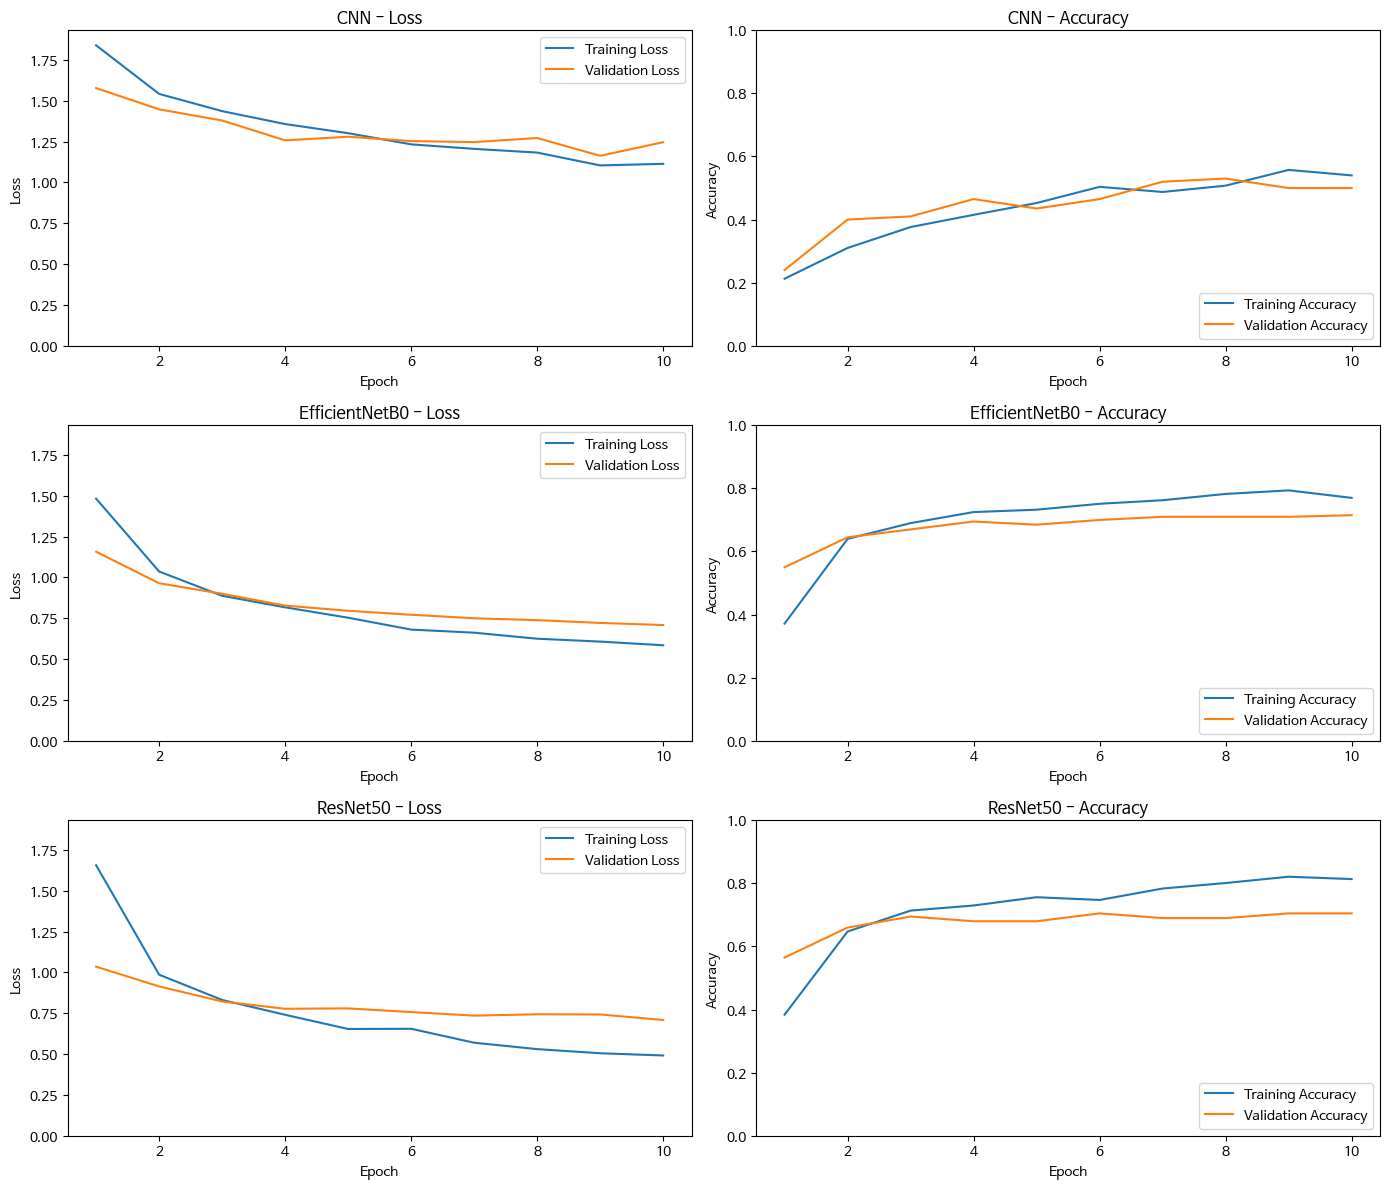

In [34]:
# 학습 곡선(모델별)
history_items = list(history_group.items())

if not history_items:
    print("학습 기록이 없습니다. 먼저 모델 학습을 실행하세요.")
else:
    max_rows = min(3, len(history_items))
    plot_models = history_items[:max_rows]

    all_loss = [
        value
        for _, history in plot_models
        for key in ('loss', 'val_loss')
        for value in history.history.get(key, [])
    ]
    loss_ylim = (0.0, max(max(all_loss) * 1.05, 1.0) if all_loss else 1.0)
    accuracy_ylim = (0.0, 1.0)

    fig, axes = plt.subplots(max_rows, 2, figsize=(14, 4 * max_rows), squeeze=False)

    for row, (name, history) in enumerate(plot_models):
        acc = history.history.get('accuracy', [])
        val_acc = history.history.get('val_accuracy', [])
        loss = history.history.get('loss', [])
        val_loss = history.history.get('val_loss', [])
        epochs_range = range(1, len(acc) + 1)

        axes[row, 0].plot(epochs_range, loss, label='Training Loss')
        axes[row, 0].plot(epochs_range, val_loss, label='Validation Loss')
        axes[row, 0].set_title(f'{name} - Loss')
        axes[row, 0].set_xlabel('Epoch')
        axes[row, 0].set_ylabel('Loss')
        axes[row, 0].set_ylim(loss_ylim)
        axes[row, 0].legend(loc='upper right')

        axes[row, 1].plot(epochs_range, acc, label='Training Accuracy')
        axes[row, 1].plot(epochs_range, val_acc, label='Validation Accuracy')
        axes[row, 1].set_title(f'{name} - Accuracy')
        axes[row, 1].set_xlabel('Epoch')
        axes[row, 1].set_ylabel('Accuracy')
        axes[row, 1].set_ylim(accuracy_ylim)
        axes[row, 1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    # ==> ResNet-50 모델의 val_loss: 0.3836가 가장 낮고, val_accuracy: 0.8600가 가장 높음
    # ==> 최적의 모델로 ResNet-50 선택

4-3. MLflow based hyperparameter tuning


In [45]:
# MLflow 설정 및 튜닝 라이브러리
MLFLOW_EXPERIMENT_NAME = "art_classifier_hyperparameter_tuning"
MLFLOW_DB_PATH = Path("./mlflow.db").resolve()
MLFLOW_ARTIFACT_DIR = Path("./mlartifacts").resolve()
MODEL_TUNING_DIR = Path("./model/mlflow_tuning").resolve()
MLFLOW_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_TUNING_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")
mlflow_client = mlflow.tracking.MlflowClient()
mlflow_experiment = mlflow_client.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)
if mlflow_experiment is None:
    mlflow_client.create_experiment(
        MLFLOW_EXPERIMENT_NAME,
        artifact_location=MLFLOW_ARTIFACT_DIR.as_uri(),
    )
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"MLflow experiment: {MLFLOW_EXPERIMENT_NAME}")
print(f"MLflow artifact directory: {MLFLOW_ARTIFACT_DIR}")
print(f"Model tuning directory: {MODEL_TUNING_DIR}")


@tf.keras.utils.register_keras_serializable(package="ArtClassifier")
def resnet50_preprocess_input_layer(x):
    return tf.keras.applications.resnet50.preprocess_input(x)


def get_tuning_custom_objects():
    return {
        "resnet50_preprocess_input_layer": resnet50_preprocess_input_layer,
        "preprocess_input": tf.keras.applications.resnet50.preprocess_input,
        "function": tf.keras.applications.resnet50.preprocess_input,
    }


def stringify_param(value):
    if isinstance(value, (list, tuple)):
        return ",".join(map(str, value))
    if value is None:
        return "None"
    return value


def flatten_params(params):
    return {key: stringify_param(value) for key, value in params.items()}


def get_optimizer(optimizer_name, learning_rate):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if optimizer_name == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    if optimizer_name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def compile_trial_model(model, params):
    loss_name = params.get("loss_name", "sparse_categorical_crossentropy")
    if loss_name != "sparse_categorical_crossentropy":
        raise ValueError("This notebook uses sparse integer labels, so sparse_categorical_crossentropy is required.")

    model.compile(
        optimizer=get_optimizer(params.get("optimizer", "adam"), params.get("learning_rate", 1e-4)),
        loss=loss_name,
        metrics=["accuracy"],
    )
    return model


def make_trial_callbacks(trial_name, patience):
    checkpoint_path = MODEL_TUNING_DIR / f"{trial_name}_best.keras"
    callbacks = [
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=0,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=0,
        ),
    ]
    return callbacks, checkpoint_path


MLflow tracking URI: sqlite:////kaggle/working/mlflow.db
MLflow experiment: art_classifier_hyperparameter_tuning
MLflow artifact directory: /kaggle/working/mlartifacts
Model tuning directory: /kaggle/working/model/mlflow_tuning


In [46]:
# Tunable model builders

def maybe_add_padding(model_layers, padding_size):
    if padding_size and padding_size > 0:
        model_layers.append(layers.ZeroPadding2D(padding=padding_size))


def build_tuned_cnn(params):
    activation = params.get("activation", "relu")
    conv_filters = params.get("conv_filters", (16, 32, 64))
    kernel_size = params.get("kernel_size", 3)
    padding_size = params.get("padding_size", 0)
    conv_padding = "valid" if padding_size > 0 else params.get("conv_padding", "same")
    dropout_rate = params.get("dropout_rate", 0.4)
    dense_units = params.get("dense_units", 128)

    model_layers = [
        layers.Input(shape=(img_height, img_width, 3)),
        make_data_augmentation(),
        layers.Rescaling(1.0 / 255),
    ]

    for filters in conv_filters:
        maybe_add_padding(model_layers, padding_size)
        model_layers.extend([
            layers.Conv2D(filters, kernel_size, padding=conv_padding, activation=activation),
            layers.MaxPooling2D(),
        ])

    model_layers.extend([
        layers.Dropout(dropout_rate),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation="softmax", name="class_output"),
    ])
    return models.Sequential(model_layers)


def build_transfer_model(backbone_name, params):
    activation = params.get("activation", "relu")
    dropout_rate = params.get("dropout_rate", 0.4)
    dense_units = params.get("dense_units", 128)
    unfreeze_layers = params.get("unfreeze_layers", 0)

    if backbone_name == "EfficientNetB0":
        base_model = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(img_height, img_width, 3),
        )
        preprocessing_layers = []
    elif backbone_name == "ResNet50":
        base_model = tf.keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(img_height, img_width, 3),
        )
        preprocessing_layers = [layers.Lambda(resnet50_preprocess_input_layer, name="resnet50_preprocess")]
    else:
        raise ValueError(f"Unsupported backbone: {backbone_name}")

    if unfreeze_layers and unfreeze_layers > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-unfreeze_layers]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
    else:
        base_model.trainable = False

    model_layers = [
        layers.Input(shape=(img_height, img_width, 3)),
        make_data_augmentation(),
        *preprocessing_layers,
        base_model,
        layers.GlobalAveragePooling2D(),
    ]

    if dense_units and dense_units > 0:
        model_layers.append(layers.Dense(dense_units, activation=activation))

    model_layers.extend([
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation="softmax", name="class_output"),
    ])
    return models.Sequential(model_layers)


def build_tuned_model(params):
    model_name = params["model_name"]
    if model_name == "CNN":
        return build_tuned_cnn(params)
    if model_name in ["EfficientNetB0", "ResNet50"]:
        return build_transfer_model(model_name, params)
    raise ValueError(f"Unsupported model_name: {model_name}")


In [47]:
# Hyperparameter search space
# output_units is fixed to num_classes because the dataset uses sparse labels for 5 classes.
mlflow_tuning_trials = [
    {
        "trial_label": "cnn_baseline_wider_dense",
        "model_name": "CNN",
        "conv_filters": (16, 32, 64),
        "kernel_size": 3,
        "padding_size": 0,
        "conv_padding": "same",
        "activation": "relu",
        "dense_units": 224,
        "dropout_rate": 0.4,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 2,
        "epochs": 10,
        "output_units": num_classes,
    },
    {
        "trial_label": "cnn_more_filters_lower_dropout",
        "model_name": "CNN",
        "conv_filters": (32, 64, 128),
        "kernel_size": 3,
        "padding_size": 1,
        "conv_padding": "valid",
        "activation": "relu",
        "dense_units": 256,
        "dropout_rate": 0.3,
        "optimizer": "adam",
        "learning_rate": 5e-4,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 3,
        "epochs": 12,
        "output_units": num_classes,
    },
    {
        "trial_label": "cnn_elu_high_dropout",
        "model_name": "CNN",
        "conv_filters": (32, 64, 128),
        "kernel_size": 3,
        "padding_size": 1,
        "conv_padding": "valid",
        "activation": "elu",
        "dense_units": 224,
        "dropout_rate": 0.5,
        "optimizer": "rmsprop",
        "learning_rate": 5e-4,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 3,
        "epochs": 12,
        "output_units": num_classes,
    },
    {
        "trial_label": "efficientnet_dense128",
        "model_name": "EfficientNetB0",
        "dense_units": 128,
        "activation": "relu",
        "dropout_rate": 0.3,
        "unfreeze_layers": 0,
        "optimizer": "adam",
        "learning_rate": 1e-4,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 2,
        "epochs": 8,
        "output_units": num_classes,
    },
    {
        "trial_label": "efficientnet_dense256_dropout05",
        "model_name": "EfficientNetB0",
        "dense_units": 256,
        "activation": "swish",
        "dropout_rate": 0.5,
        "unfreeze_layers": 0,
        "optimizer": "adam",
        "learning_rate": 5e-5,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 3,
        "epochs": 10,
        "output_units": num_classes,
    },
    {
        "trial_label": "resnet_gap_only",
        "model_name": "ResNet50",
        "dense_units": 0,
        "activation": "relu",
        "dropout_rate": 0.4,
        "unfreeze_layers": 0,
        "optimizer": "adam",
        "learning_rate": 1e-4,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 2,
        "epochs": 8,
        "output_units": num_classes,
    },
    {
        "trial_label": "resnet_dense128_dropout03",
        "model_name": "ResNet50",
        "dense_units": 128,
        "activation": "relu",
        "dropout_rate": 0.3,
        "unfreeze_layers": 0,
        "optimizer": "adam",
        "learning_rate": 1e-4,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 2,
        "epochs": 8,
        "output_units": num_classes,
    },
    {
        "trial_label": "resnet_unfreeze20_dense256",
        "model_name": "ResNet50",
        "dense_units": 256,
        "activation": "relu",
        "dropout_rate": 0.4,
        "unfreeze_layers": 20,
        "optimizer": "adam",
        "learning_rate": 1e-5,
        "loss_name": "sparse_categorical_crossentropy",
        "patience": 3,
        "epochs": 10,
        "output_units": num_classes,
    },
]

print(f"Prepared {len(mlflow_tuning_trials)} MLflow tuning trials.")


Prepared 8 MLflow tuning trials.


In [48]:
# Run MLflow tuning experiments
RUN_MLFLOW_TUNING = True
MLFLOW_TUNING_MAX_TRIALS = None  # Example: set to 2 for a quick smoke test.
MLFLOW_LOG_MODEL_ARTIFACTS = False  # Set True if you want each Keras model copied into MLflow artifacts.


def run_single_mlflow_trial(params, trial_index):
    trial_name = f"{trial_index:02d}_{params['trial_label']}"
    checkpoint_path = None
    history = None
    model = None

    with mlflow.start_run(run_name=trial_name) as run:
        mlflow.set_tags({
            "stage": "hyperparameter_tuning",
            "selection_rule": "min_val_loss_then_max_val_accuracy",
            "model_name": params["model_name"],
        })
        mlflow.log_params(flatten_params(params))

        try:
            tf.keras.backend.clear_session()
            model = compile_trial_model(build_tuned_model(params), params)
            callbacks, checkpoint_path = make_trial_callbacks(trial_name, params.get("patience", 2))

            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=params.get("epochs", 8),
                callbacks=callbacks,
                verbose=1,
            )

            val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
            train_loss = history.history.get("loss", [np.nan])[-1]
            train_accuracy = history.history.get("accuracy", [np.nan])[-1]
            val_loss_history = history.history.get("val_loss", [val_loss])
            val_accuracy_history = history.history.get("val_accuracy", [val_accuracy])
            best_epoch_index = int(np.argmin(val_loss_history))

            metrics = {
                "train_loss": float(train_loss),
                "train_accuracy": float(train_accuracy),
                "val_loss": float(val_loss),
                "val_accuracy": float(val_accuracy),
                "best_val_loss": float(np.min(val_loss_history)),
                "best_val_accuracy": float(val_accuracy_history[best_epoch_index]),
                "best_epoch": best_epoch_index + 1,
                "epochs_ran": len(history.history.get("loss", [])),
            }
            mlflow.log_metrics(metrics)

            history_path = MODEL_TUNING_DIR / f"{trial_name}_history.csv"
            pd.DataFrame(history.history).to_csv(history_path, index=False)
            mlflow.log_artifact(str(history_path), artifact_path="history")

            if checkpoint_path is not None and checkpoint_path.exists():
                mlflow.log_param("checkpoint_path", str(checkpoint_path))
                if MLFLOW_LOG_MODEL_ARTIFACTS:
                    mlflow.log_artifact(str(checkpoint_path), artifact_path="keras_model")

            mlflow.set_tag("trial_status", "success")
            result = {
                "status": "success",
                "trial_name": trial_name,
                "run_id": run.info.run_id,
                "model_path": str(checkpoint_path) if checkpoint_path else None,
                **flatten_params(params),
                **metrics,
            }

        except Exception as exc:
            mlflow.set_tag("trial_status", "failed")
            mlflow.log_param("error_type", type(exc).__name__)
            mlflow.log_text(traceback.format_exc(), artifact_file="error_traceback.txt")
            print(f"Trial failed: {trial_name} - {type(exc).__name__}: {exc}")
            result = {
                "status": "failed",
                "trial_name": trial_name,
                "run_id": run.info.run_id,
                **flatten_params(params),
                "error": f"{type(exc).__name__}: {exc}",
            }

        finally:
            if model is not None:
                del model
            tf.keras.backend.clear_session()
            gc.collect()

    return result, history


def run_mlflow_tuning_experiments(trials, max_trials=None):
    selected_trials = trials[:max_trials] if max_trials else trials
    results = []
    histories = {}

    for trial_index, params in enumerate(selected_trials, start=1):
        print(f"\n===== MLflow tuning trial {trial_index}/{len(selected_trials)}: {params['trial_label']} =====")
        result, history = run_single_mlflow_trial(params, trial_index)
        results.append(result)
        if result.get("status") == "success" and history is not None:
            histories[result["trial_name"]] = history

    results_df = pd.DataFrame(results)
    results_path = MODEL_TUNING_DIR / "mlflow_tuning_results.csv"
    results_df.to_csv(results_path, index=False)
    print(f"\nSaved tuning results: {results_path}")

    return results, results_df, histories


if RUN_MLFLOW_TUNING:
    mlflow_tuning_results, mlflow_tuning_results_df, tuned_history_group = run_mlflow_tuning_experiments(
        mlflow_tuning_trials,
        max_trials=MLFLOW_TUNING_MAX_TRIALS,
    )
else:
    print("RUN_MLFLOW_TUNING is False. Set it to True to run experiments.")



===== MLflow tuning trial 1/8: cnn_baseline_wider_dense =====
Epoch 1/10


E0000 00:00:1782802953.489299      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 416ms/step - accuracy: 0.2350 - loss: 1.7709 - val_accuracy: 0.3750 - val_loss: 1.5283
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 383ms/step - accuracy: 0.3500 - loss: 1.4579 - val_accuracy: 0.4150 - val_loss: 1.3761
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - accuracy: 0.4400 - loss: 1.3216 - val_accuracy: 0.4100 - val_loss: 1.3342
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 361ms/step - accuracy: 0.4300 - loss: 1.2833 - val_accuracy: 0.3600 - val_loss: 1.4874
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 385ms/step - accuracy: 0.4600 - loss: 1.2503 - val_accuracy: 0.5150 - val_loss: 1.2528
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - accuracy: 0.4888 - loss: 1.2423 - val_accuracy: 0.4500 - val_loss: 1.5727
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - accuracy: 0.5188 - loss: 1.1838 - val_accuracy: 0.4750 - val_loss: 1.3314

===== MLflow tuning trial 2/8: cnn_more_filters_lower_dropout =====
Epoch 1/12


E0000 00:00:1782803027.274809      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 441ms/step - accuracy: 0.2400 - loss: 2.1187 - val_accuracy: 0.2750 - val_loss: 1.6229
Epoch 2/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 427ms/step - accuracy: 0.3088 - loss: 1.5524 - val_accuracy: 0.3500 - val_loss: 1.4843
Epoch 3/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 427ms/step - accuracy: 0.4162 - loss: 1.4108 - val_accuracy: 0.4600 - val_loss: 1.3357
Epoch 4/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 421ms/step - accuracy: 0.4187 - loss: 1.3480 - val_accuracy: 0.4750 - val_loss: 1.2986
Epoch 5/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 427ms/step - accuracy: 0.4888 - loss: 1.2602 - val_accuracy: 0.5000 - val_loss: 1.2320
Epoch 6/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 416ms/step - accuracy: 0.4950 - loss: 1.1984 - val_accuracy: 0.5350 - val_loss: 1.1809
Epoch 7/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 348ms/step - accuracy: 0.5163 - loss: 1.1620 - val_accuracy: 0.4100 - val_loss: 1.4710
Epoch 8/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step - accuracy: 0.5288 - loss: 1.1389 - val_accuracy: 0.5400 

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step - accuracy: 0.3050 - loss: 5.7543 - val_accuracy: 0.4000 - val_loss: 1.5099
Epoch 2/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - accuracy: 0.3250 - loss: 1.9270 - val_accuracy: 0.4650 - val_loss: 1.4238
Epoch 3/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 341ms/step - accuracy: 0.3613 - loss: 1.7451 - val_accuracy: 0.3050 - val_loss: 1.8627
Epoch 4/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 370ms/step - accuracy: 0.3787 - loss: 1.8010 - val_accuracy: 0.3950 - val_loss: 1.5400
Epoch 5/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 400ms/step - accuracy: 0.4162 - loss: 1.5749 - val_accuracy: 0.4750 - val_loss: 1.3300
Epoch 6/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 354ms/step - accuracy: 0.4350 - loss: 1.5179 - val_accuracy: 0.4050 - val_loss: 1.5657
Epoch 7/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 352ms/step - accuracy: 0.4387 - loss: 1.4847 - val_accuracy: 0.3800 - val_loss: 1.4379
Epoch 8/12
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 394ms/step - accuracy: 0.4600 - loss: 1.4083 - val_accuracy: 0.5300 - 

E0000 00:00:1782803252.234376      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 479ms/step - accuracy: 0.2862 - loss: 1.5974 - val_accuracy: 0.4200 - val_loss: 1.4326
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 387ms/step - accuracy: 0.4825 - loss: 1.3472 - val_accuracy: 0.5250 - val_loss: 1.2741
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 374ms/step - accuracy: 0.5800 - loss: 1.1852 - val_accuracy: 0.5850 - val_loss: 1.1571
Epoch 4/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 387ms/step - accuracy: 0.6350 - loss: 1.0538 - val_accuracy: 0.6350 - val_loss: 1.0711
Epoch 5/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step - accuracy: 0.6700 - loss: 0.9849 - val_accuracy: 0.6650 - val_loss: 1.0030
Epoch 6/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - accuracy: 0.6988 - loss: 0.8990 - val_accuracy: 0.6750 - val_loss: 0.9550
Epoch 7/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 406ms/step - accuracy: 0.7113 - loss: 0.8493 - val_accuracy: 0.6700 - val_loss: 0.9172
Epoch 8/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 373ms/step - accuracy: 0.7125 - loss: 0.8220 - val_accuracy: 0.6800 - val

E0000 00:00:1782803349.081229      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 498ms/step - accuracy: 0.2125 - loss: 1.6801 - val_accuracy: 0.3000 - val_loss: 1.5645
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 403ms/step - accuracy: 0.3663 - loss: 1.4843 - val_accuracy: 0.4250 - val_loss: 1.4331
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 405ms/step - accuracy: 0.4675 - loss: 1.3713 - val_accuracy: 0.5250 - val_loss: 1.3261
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 395ms/step - accuracy: 0.5325 - loss: 1.2493 - val_accuracy: 0.5700 - val_loss: 1.2354
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 371ms/step - accuracy: 0.5850 - loss: 1.1545 - val_accuracy: 0.5950 - val_loss: 1.1633
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - accuracy: 0.6413 - loss: 1.0887 - val_accuracy: 0.6150 - val_loss: 1.1054
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.6413 - loss: 1.0202 - val_accuracy: 0.6350 - val_loss: 1.0576
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - accuracy: 0.6650 - loss: 0.9801 - val_accuracy: 0.645

In [58]:
# Select and save the best tuned model
if "mlflow_tuning_results_df" not in globals() or mlflow_tuning_results_df.empty:
    raise RuntimeError("No MLflow tuning results found. Run the tuning experiment cell first.")

successful_trials = mlflow_tuning_results_df[mlflow_tuning_results_df["status"] == "success"].copy()
if successful_trials.empty:
    raise RuntimeError("All MLflow tuning trials failed. Check MLflow run artifacts for error_traceback.txt.")

successful_trials = successful_trials.sort_values(
    by=["val_loss", "val_accuracy"],
    ascending=[True, False],
).reset_index(drop=True)

mlflow_best_trial = successful_trials.iloc[0].to_dict()
mlflow_best_model_source_path = Path(mlflow_best_trial["model_path"])
mlflow_best_model_path = Path("./model/MLflow_Best_ArtClassifier.keras").resolve()

if not mlflow_best_model_source_path.exists():
    raise FileNotFoundError(f"Best model checkpoint not found: {mlflow_best_model_source_path}")

shutil.copy2(mlflow_best_model_source_path, mlflow_best_model_path)

# Keep compatibility with the existing comparison cells.
tuned_eval_group = {
    row["trial_name"]: {"loss": row["val_loss"], "accuracy": row["val_accuracy"]}
    for _, row in successful_trials.iterrows()
}

print("[Best MLflow tuned model]")
print(f"Trial: {mlflow_best_trial['trial_name']}")
print(f"Model: {mlflow_best_trial['model_name']}")
print(f"val_loss: {mlflow_best_trial['val_loss']:.4f}")
print(f"val_accuracy: {mlflow_best_trial['val_accuracy']:.4f}")
print(f"Saved best model to: {mlflow_best_model_path}")

display_cols = [
    "trial_name", "model_name", "val_loss", "val_accuracy", "best_epoch", "epochs_ran",
    "optimizer", "learning_rate", "activation", "dropout_rate", "dense_units", "patience",
]
display(successful_trials[[col for col in display_cols if col in successful_trials.columns]])


[Best MLflow tuned model]
Trial: 07_resnet_dense128_dropout03
Model: ResNet50
val_loss: 0.7361
val_accuracy: 0.7400
Saved best model to: /kaggle/working/model/MLflow_Best_ArtClassifier.keras


,trial_name,model_name,val_loss,val_accuracy,best_epoch,epochs_ran,optimizer,learning_rate,activation,dropout_rate,dense_units,patience
0,07_resnet_dense128_dropout03,ResNet50,0.736121,0.740,8,8,adam,0.00010,relu,0.3,128,2
1,08_resnet_unfreeze20_dense256,ResNet50,0.797845,0.685,10,10,adam,0.00001,relu,0.4,256,3
2,04_efficientnet_dense128,EfficientNetB0,0.889924,0.680,8,8,adam,0.00010,relu,0.3,128,2
3,05_efficientnet_dense256_dropout05,EfficientNetB0,0.952759,0.675,10,10,adam,0.00005,swish,0.5,256,3
4,06_resnet_gap_only,ResNet50,1.148504,0.510,8,8,adam,0.00010,relu,0.4,0,2
5,02_cnn_more_filters_lower_dropout,CNN,1.180943,0.535,6,9,adam,0.00050,relu,0.3,256,3
6,03_cnn_elu_high_dropout,CNN,1.220164,0.515,11,12,rmsprop,0.00050,elu,0.5,224,3
7,01_cnn_baseline_wider_dense,CNN,1.252758,0.515,5,7,adam,0.00100,relu,0.4,224,2


In [59]:
# Optional: read tuning runs back from MLflow
experiment = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)
if experiment is None:
    print("MLflow experiment not found yet.")
else:
    mlflow_runs_df = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.stage = 'hyperparameter_tuning'",
        order_by=["metrics.val_loss ASC", "metrics.val_accuracy DESC"],
    )
    print(f"MLflow runs found: {len(mlflow_runs_df)}")
    if not mlflow_runs_df.empty:
        display_cols = [
            "run_id", "tags.model_name", "tags.trial_status",
            "metrics.val_loss", "metrics.val_accuracy",
            "metrics.best_epoch", "params.trial_label",
            "params.optimizer", "params.learning_rate",
            "params.dropout_rate", "params.dense_units",
        ]
        display(mlflow_runs_df[[col for col in display_cols if col in mlflow_runs_df.columns]].head(20))

print("To open the MLflow UI, run this in a terminal:")
print(f"mlflow ui --backend-store-uri {mlflow.get_tracking_uri()}")


MLflow runs found: 16


,run_id,tags.model_name,tags.trial_status,metrics.val_loss,metrics.val_accuracy,metrics.best_epoch,params.trial_label,params.optimizer,params.learning_rate,params.dropout_rate,params.dense_units
0,dcea535f42584829b860b48b55821d77,ResNet50,success,0.736121,0.740,8.0,resnet_dense128_dropout03,adam,0.0001,0.3,128
1,6006ebc3308047438b6edc874fead8b0,ResNet50,success,0.776929,0.735,7.0,resnet_dense128_dropout03,adam,0.0001,0.3,128
2,95af20c8a748498a86352790793e77bf,ResNet50,success,0.788301,0.705,10.0,resnet_unfreeze20_dense256,adam,1e-05,0.4,256
3,447364c7d489474ea59e9770229f18d1,ResNet50,success,0.797845,0.685,10.0,resnet_unfreeze20_dense256,adam,1e-05,0.4,256
4,ebe836f6b80b415e93704a4c2293ac56,EfficientNetB0,success,0.863706,0.710,8.0,efficientnet_dense128,adam,0.0001,0.3,128
5,6af0313b049240dd9498e7366d3b6511,EfficientNetB0,success,0.889924,0.680,8.0,efficientnet_dense128,adam,0.0001,0.3,128
6,aae4d3c10629400cad6052cbcd3771d7,EfficientNetB0,success,0.944129,0.650,10.0,efficientnet_dense256_dropout05,adam,5e-05,0.5,256
7,eb9e928ed58d49e2a4f989307ba30869,EfficientNetB0,success,0.952759,0.675,10.0,efficientnet_dense256_dropout05,adam,5e-05,0.5,256
8,25400978940e4af4aa531da52e65bd41,ResNet50,success,1.148504,0.510,8.0,resnet_gap_only,adam,0.0001,0.4,0
9,ecce9449b48a464599fa71981c0ba47f,CNN,success,1.148509,0.515,6.0,cnn_baseline_wider_dense,adam,0.001,0.4,224


To open the MLflow UI, run this in a terminal:
mlflow ui --backend-store-uri sqlite:////kaggle/working/mlflow.db


5. 최종 모델 선정

5-1. 모델별 성능 비교

#학습 결과 및 성능 비교 (model evaluate)

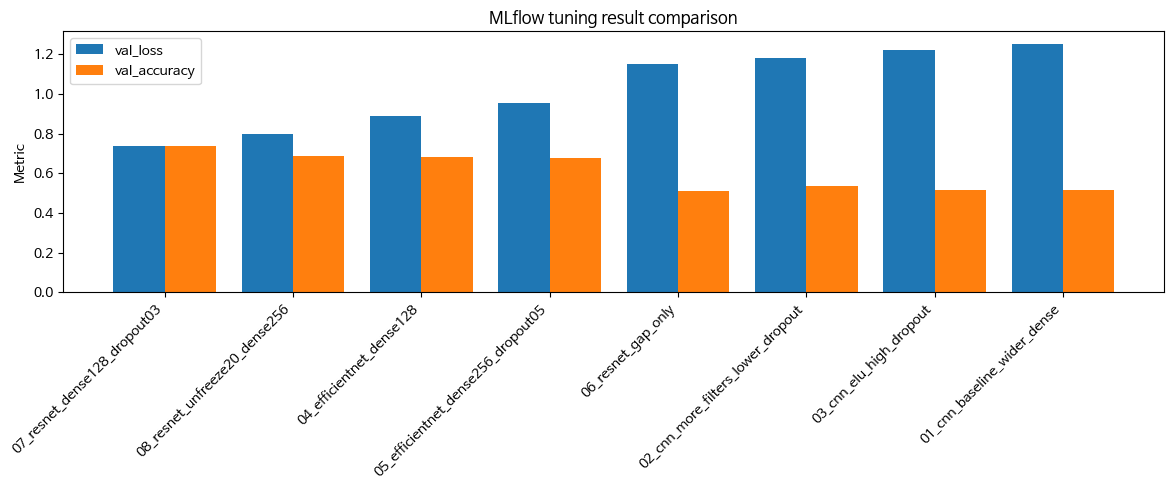

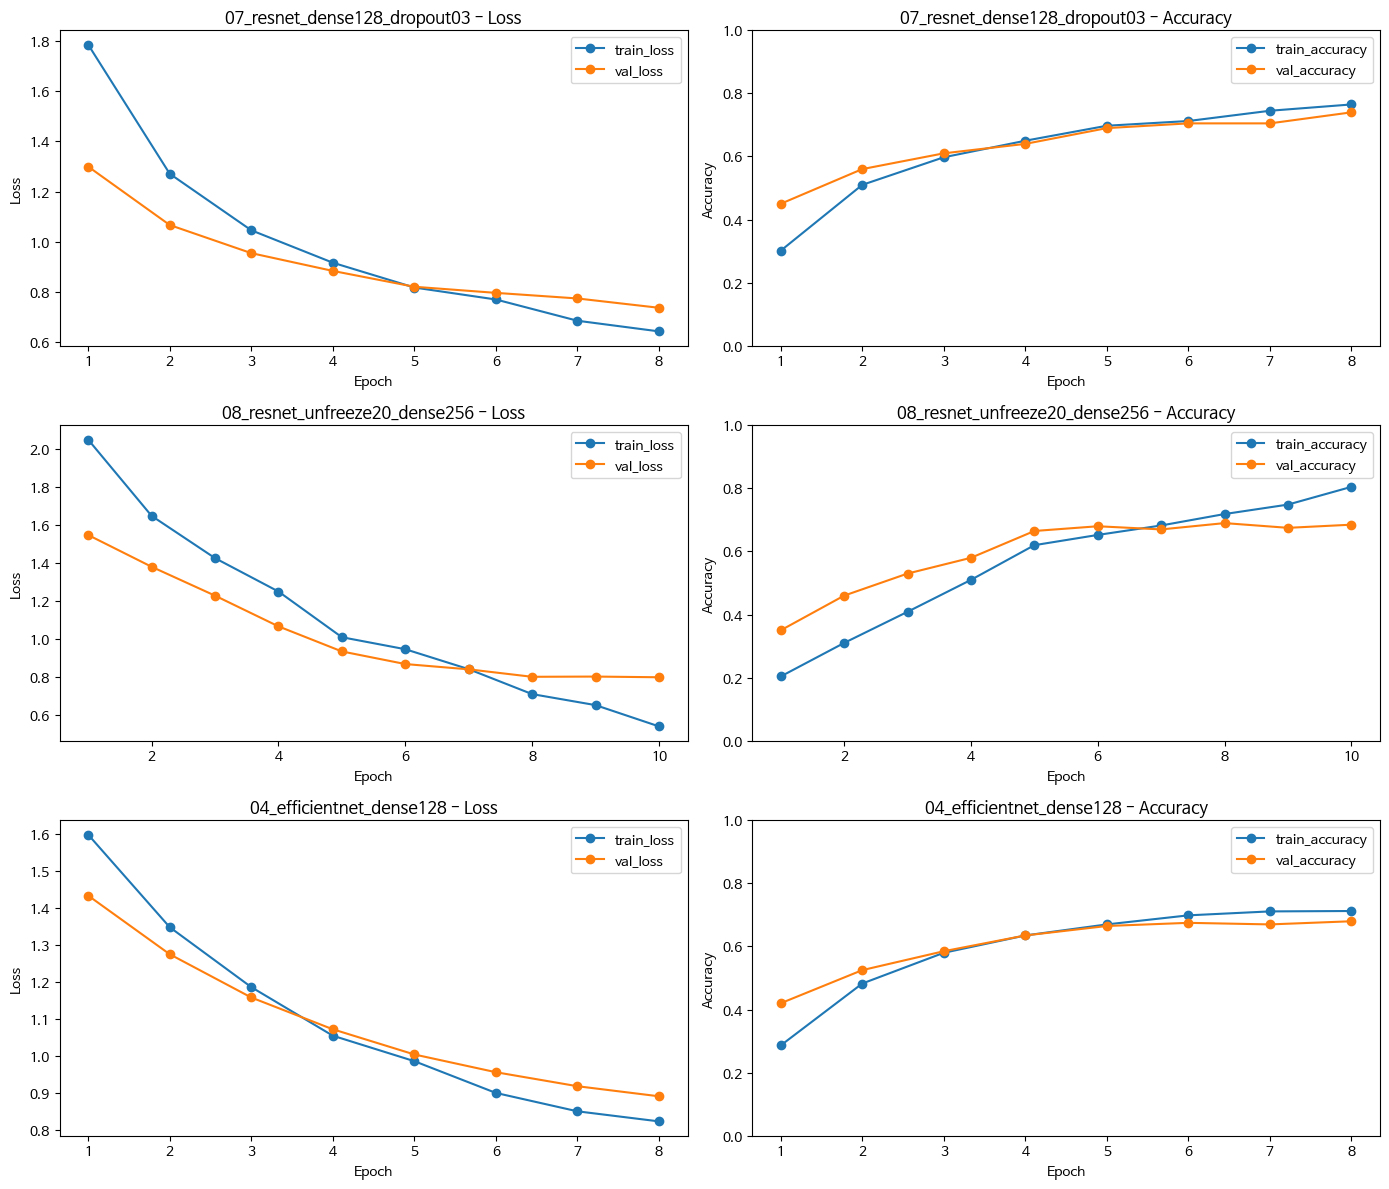

In [60]:
# MLflow tuning result visualization
if "mlflow_tuning_results_df" not in globals() or mlflow_tuning_results_df.empty:
    print("No MLflow tuning results found. Run the MLflow tuning cells first.")
elif "tuned_history_group" not in globals() or not tuned_history_group:
    print("No tuning histories found. Run the MLflow tuning experiment cell first.")
else:
    successful_trials = mlflow_tuning_results_df[mlflow_tuning_results_df["status"] == "success"].copy()
    successful_trials = successful_trials.sort_values(
        by=["val_loss", "val_accuracy"],
        ascending=[True, False],
    ).reset_index(drop=True)

    plt.figure(figsize=(12, 5))
    x = np.arange(len(successful_trials))
    plt.bar(x - 0.2, successful_trials["val_loss"], width=0.4, label="val_loss")
    plt.bar(x + 0.2, successful_trials["val_accuracy"], width=0.4, label="val_accuracy")
    plt.xticks(x, successful_trials["trial_name"], rotation=45, ha="right")
    plt.title("MLflow tuning result comparison")
    plt.ylabel("Metric")
    plt.legend()
    plt.tight_layout()
    plt.show()

    top_trial_names = successful_trials["trial_name"].head(3).tolist()
    fig, axes = plt.subplots(len(top_trial_names), 2, figsize=(14, 4 * len(top_trial_names)), squeeze=False)

    for row, trial_name in enumerate(top_trial_names):
        history = tuned_history_group.get(trial_name)
        if history is None:
            continue

        loss = history.history.get("loss", [])
        val_loss = history.history.get("val_loss", [])
        acc = history.history.get("accuracy", [])
        val_acc = history.history.get("val_accuracy", [])
        epochs_range = range(1, len(loss) + 1)

        axes[row, 0].plot(epochs_range, loss, marker="o", label="train_loss")
        axes[row, 0].plot(epochs_range, val_loss, marker="o", label="val_loss")
        axes[row, 0].set_title(f"{trial_name} - Loss")
        axes[row, 0].set_xlabel("Epoch")
        axes[row, 0].set_ylabel("Loss")
        axes[row, 0].legend()

        axes[row, 1].plot(epochs_range, acc, marker="o", label="train_accuracy")
        axes[row, 1].plot(epochs_range, val_acc, marker="o", label="val_accuracy")
        axes[row, 1].set_title(f"{trial_name} - Accuracy")
        axes[row, 1].set_xlabel("Epoch")
        axes[row, 1].set_ylabel("Accuracy")
        axes[row, 1].set_ylim(0, 1)
        axes[row, 1].legend()

    plt.tight_layout()
    plt.show()


6. 최종 모델 저장(07_resnet_dense128_dropout03)

In [72]:
#MLflow 실험 후 최적의 모델을 찾아오기
experiment_name = "art_classifier_hyperparameter_tuning"


def has_text(value):
    text = "" if value is None else str(value).strip()
    return bool(text) and text.lower() not in {"nan", "none"}


def find_logged_keras_artifact(client, run_id):
    # If MLFLOW_LOG_MODEL_ARTIFACTS=True was used, the .keras file is stored under keras_model/.
    for artifact_dir in ["keras_model", None]:
        try:
            artifacts = client.list_artifacts(run_id, artifact_dir) if artifact_dir else client.list_artifacts(run_id)
        except Exception:
            continue

        for artifact in artifacts:
            if not artifact.is_dir and artifact.path.endswith(".keras"):
                return artifact.path
    return None


def get_final_model_path():
    output_root = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".").resolve()
    final_model_path = output_root / "model" / "artClassifier_model.keras"
    final_model_path.parent.mkdir(parents=True, exist_ok=True)
    return final_model_path


print("Searching MLflow runs for the best model...")
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    print(f"Experiment not found: {experiment_name}")
else:
    runs_df = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.stage = 'hyperparameter_tuning'",
    )

    if "tags.trial_status" in runs_df.columns:
        runs_df = runs_df[runs_df["tags.trial_status"] == "success"]
    if "metrics.val_loss" in runs_df.columns:
        runs_df = runs_df.dropna(subset=["metrics.val_loss"])

    if runs_df.empty:
        print("No successful tuning runs found. Run the MLflow tuning cell first.")
    else:
        sort_columns = ["metrics.val_loss"]
        ascending = [True]
        if "metrics.val_accuracy" in runs_df.columns:
            sort_columns.append("metrics.val_accuracy")
            ascending.append(False)

        best_run = runs_df.sort_values(by=sort_columns, ascending=ascending).iloc[0]
        best_run_id = best_run["run_id"]
        best_val_loss = best_run["metrics.val_loss"]
        best_val_accuracy = best_run.get("metrics.val_accuracy", float("nan"))
        print(
            f"Best Run ID: {best_run_id} "
            f"(val_loss: {best_val_loss:.4f}, val_accuracy: {best_val_accuracy:.4f})"
        )

        client = MlflowClient()
        run = client.get_run(best_run_id)
        model_source_path = None

        checkpoint_path_text = run.data.params.get("checkpoint_path")
        if has_text(checkpoint_path_text):
            checkpoint_path = Path(checkpoint_path_text)
            if checkpoint_path.exists():
                model_source_path = checkpoint_path
            else:
                print(f"checkpoint_path recorded in the run is not available in this session: {checkpoint_path}")

        if model_source_path is None:
            local_best_path = Path("./model/artClassifier_model.keras").resolve()
            if local_best_path.exists():
                model_source_path = local_best_path
                print(f"Using local best model file: {local_best_path}")

        if model_source_path is None:
            keras_artifact_path = find_logged_keras_artifact(client, best_run_id)
            if keras_artifact_path is not None:
                downloaded_path = client.download_artifacts(best_run_id, keras_artifact_path)
                model_source_path = Path(downloaded_path)


        #최종 모델 저장
        final_path = get_final_model_path()

        if model_source_path is not None:
            shutil.copy2(model_source_path, final_path)
            print(f"Final model saved to: {final_path}")
        else:
            try:
                # This works only for runs saved with mlflow.keras.log_model(..., artifact_path/name='keras_model').
                best_model = mlflow.keras.load_model(f"runs:/{best_run_id}/keras_model")
                best_model.save(final_path)
                print(f"Final model saved to: {final_path}")
            except Exception as exc:
                raise FileNotFoundError(
                    "No loadable model file was found for this run. The current tuning cell does not save "
                    "model artifacts to MLflow by default; it records only the local checkpoint_path. "
                    "To restore from a fresh session, rerun tuning with MLFLOW_LOG_MODEL_ARTIFACTS=True "
                    "or use the ./model/MLflow_Best_ArtClassifier.keras file created by the model selection cell."
                ) from exc

Searching MLflow runs for the best model...
Best Run ID: dcea535f42584829b860b48b55821d77 (val_loss: 0.7361, val_accuracy: 0.7400)
Final model saved to: /kaggle/working/model/artClassifier_model.keras


7. 최종 모델의 성능 분석

#새로운 테스트 데이터로 예측

1. 새로운 테스트 데이터 예측 (Mona Lisa, San Vitale)


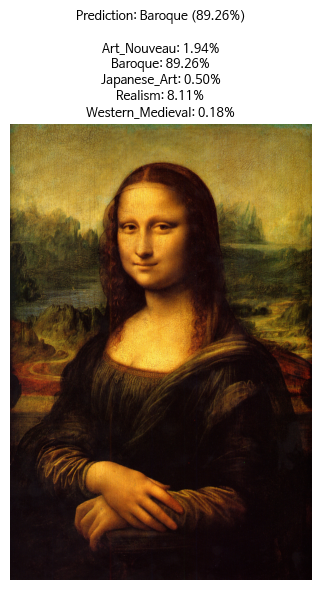

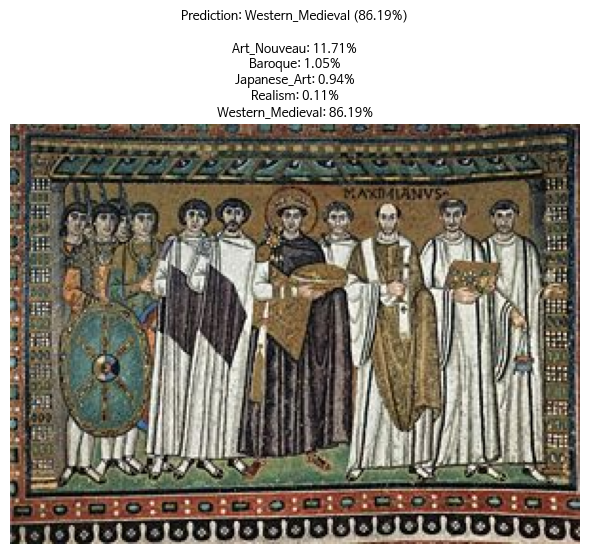

In [73]:
print("=========================================================")
print("1. 새로운 테스트 데이터 예측 (Mona Lisa, San Vitale)")
print("=========================================================")

# 1. 모델 불러오기
model_path = '/kaggle/working/model/artClassifier_model.keras'
final_model = tf.keras.models.load_model(model_path)

# 2. 클래스 이름 정의 (반드시 본인의 데이터셋에 맞게 수정!)
class_names = [
    "Art_Nouveau",
    "Baroque",
    "Japanese_Art",
    "Realism",
    "Western_Medieval",
]

image_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/6/6a/Mona_Lisa.jpg",
    "https://www.newworldencyclopedia.org/d/images/thumb/6/66/Meister_von_San_Vitale_in_Ravenna_003.jpg/300px-Meister_von_San_Vitale_in_Ravenna_003.jpg"
]

for url in image_urls:
    # 403 Forbidden 방지를 위해 User-Agent 추가하여 이미지 로드
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        img = Image.open(response).convert('RGB')
    
    # 모델 입력 형태(224x224)에 맞게 변환
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized)
    
    # [주의] 스케일링을 했다면 주석 해제
    # img_array = img_array / 255.0
    
    img_batch = np.expand_dims(img_array, axis=0) 
    
    # 예측
    predictions = final_model.predict(img_batch, verbose=0)
    
    # 가장 높은 확률을 가진 클래스 찾기
    # Convert model output to percentage values for every class.
    probabilities = predictions[0] * 100
    if len(probabilities) != len(class_names):
        raise ValueError(
            f"class_names has {len(class_names)} labels, "
            f"but model returned {len(probabilities)} probabilities."
        )

    # Find the class with the highest probability.
    pred_index = np.argmax(probabilities)
    pred_class = class_names[pred_index]
    confidence = probabilities[pred_index]
    probability_title = "\n".join(
        f"{class_name}: {prob:.2f}%"
        for class_name, prob in zip(class_names, probabilities)
    )
    
    # 1) 이미지 및 최고 확신도 출력
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(
        f"Prediction: {pred_class} ({confidence:.2f}%)\n\n{probability_title}",
        fontsize=9,
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()


#분류 리포트 출력

In [74]:
# =====================================================================
# 2. Classification report
# =====================================================================
def resolve_final_model_path():
    candidates = [
        Path("/kaggle/working/model/artClassifier_model.keras"),
        Path("./model/artClassifier_model.keras").resolve(),
        Path("/kaggle/working/model/MLflow_Best_ArtClassifier.keras"),
        Path("./model/MLflow_Best_ArtClassifier.keras").resolve(),
        Path("./model/ResNet50_Final_Classifier.keras").resolve(),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No final model file found. Run the final model save cell first.")


def load_final_model_for_analysis():
    model_path = resolve_final_model_path()
    custom_objects = get_tuning_custom_objects() if "get_tuning_custom_objects" in globals() else None
    try:
        model = tf.keras.models.load_model(
            model_path,
            custom_objects=custom_objects,
            compile=False,
            safe_mode=False,
        )
    except TypeError:
        model = tf.keras.models.load_model(
            model_path,
            custom_objects=custom_objects,
            compile=False,
        )
    print(f"Loaded final model: {model_path}")
    return model


def ensure_class_names():
    if "class_names" in globals() and len(class_names) > 0:
        return list(class_names)
    if "SELECTED_CLASSES" in globals() and len(SELECTED_CLASSES) > 0:
        return list(SELECTED_CLASSES)
    raise RuntimeError("class_names is not defined. Run the dataset setup cell first.")


def predict_validation_dataset(model, dataset):
    true_labels = []
    pred_labels = []
    pred_probs = []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        pred_probs.append(probabilities)
        pred_labels.extend(np.argmax(probabilities, axis=1).astype(int).tolist())
        true_labels.extend(labels.numpy().astype(int).tolist())

    return (
        np.array(true_labels, dtype=int),
        np.array(pred_labels, dtype=int),
        np.vstack(pred_probs),
    )


if "val_ds" not in globals():
    raise RuntimeError("val_ds is not defined. Run the dataset creation cell first.")

class_names = ensure_class_names()
if "final_model" not in globals():
    final_model = load_final_model_for_analysis()

y_true, y_pred, y_prob = predict_validation_dataset(final_model, val_ds)

if y_prob.shape[1] != len(class_names):
    raise ValueError(
        f"class_names has {len(class_names)} labels, "
        f"but model returned {y_prob.shape[1]} probabilities."
    )

print("\n[Classification Report - Validation Data]")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

classification_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).transpose()
display(classification_report_df)

validation_accuracy = accuracy_score(y_true, y_pred)
print(f"Validation accuracy: {validation_accuracy:.4f}")



[Classification Report - Validation Data]
                  precision    recall  f1-score   support

     Art_Nouveau       0.63      0.72      0.67        40
         Baroque       0.75      0.68      0.71        40
    Japanese_Art       0.87      0.68      0.76        40
         Realism       0.65      0.78      0.70        40
Western_Medieval       0.87      0.85      0.86        40

        accuracy                           0.74       200
       macro avg       0.75      0.74      0.74       200
    weighted avg       0.75      0.74      0.74       200



,precision,recall,f1-score,support
Art_Nouveau,0.630435,0.725,0.674419,40.00
Baroque,0.750000,0.675,0.710526,40.00
Japanese_Art,0.870968,0.675,0.760563,40.00
Realism,0.645833,0.775,0.704545,40.00
Western_Medieval,0.871795,0.850,0.860759,40.00
accuracy,0.740000,0.740,0.740000,0.74
macro avg,0.753806,0.740,0.742163,200.00
weighted avg,0.753806,0.740,0.742163,200.00


Validation accuracy: 0.7400


#K폴드 교차검증 - 성능 지표 분석 (Accuracy, Precision, Recall, F1-score)

In [84]:
print("\n=========================================================")
print("5. K-fold cross validation")
print("=========================================================")

RUN_KFOLD = True
KFOLD_SPLITS = 5
KFOLD_EPOCHS = 5

if "train_paths" not in globals() or "val_paths" not in globals():
    raise RuntimeError("train_paths/val_paths are not defined. Run the dataset split cell first.")
if "build_tuned_model" not in globals() or "compile_trial_model" not in globals():
    raise RuntimeError("Tuned model builders are not defined. Run the MLflow tuning setup cells first.")

all_paths = np.array(list(train_paths) + list(val_paths))
all_labels = np.array(list(train_labels) + list(val_labels), dtype=int)
class_names = ensure_class_names() if "ensure_class_names" in globals() else list(class_names)

kfold_params = {
    "trial_label": "resnet_dense128_dropout03_kfold",
    "model_name": "ResNet50",
    "activation": "relu",
    "dense_units": 128,
    "dropout_rate": 0.3,
    "optimizer": "adam",
    "learning_rate": 1e-4,
    "loss_name": "sparse_categorical_crossentropy",
    "patience": 2,
    "epochs": KFOLD_EPOCHS,
    "unfreeze_layers": 0,
    "output_units": len(class_names),
}


def make_path_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels.tolist()))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    return (
        ds.map(load_image, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )


if not RUN_KFOLD:
    print("RUN_KFOLD is False. Set it to True to train and evaluate all folds.")
else:
    kfold = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=SEED)
    kfold_results = []
    kfold_histories = {}

    for fold_no, (train_idx, val_idx) in enumerate(kfold.split(all_paths, all_labels), start=1):
        print(f"\n--- Fold {fold_no}/{KFOLD_SPLITS} training start ---")

        fold_train_ds = make_path_dataset(all_paths[train_idx], all_labels[train_idx], training=True)
        fold_val_ds = make_path_dataset(all_paths[val_idx], all_labels[val_idx], training=False)

        tf.keras.backend.clear_session()
        kfold_model = compile_trial_model(build_tuned_model(kfold_params), kfold_params)
        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=kfold_params["patience"],
                restore_best_weights=True,
                verbose=1,
            )
        ]

        history = kfold_model.fit(
            fold_train_ds,
            validation_data=fold_val_ds,
            epochs=kfold_params["epochs"],
            callbacks=callbacks,
            verbose=1,
        )
        fold_loss, fold_accuracy = kfold_model.evaluate(fold_val_ds, verbose=0)

        fold_true, fold_pred, _ = predict_validation_dataset(kfold_model, fold_val_ds)
        precision, recall, f1, _ = precision_recall_fscore_support(
            fold_true,
            fold_pred,
            average="weighted",
            zero_division=0,
        )

        kfold_results.append({
            "fold": fold_no,
            "loss": float(fold_loss),
            "accuracy": float(fold_accuracy),
            "precision_weighted": float(precision),
            "recall_weighted": float(recall),
            "f1_weighted": float(f1),
            "epochs_ran": len(history.history.get("loss", [])),
        })
        kfold_histories[f"fold_{fold_no}"] = history.history

        print(
            f"Fold {fold_no} - loss: {fold_loss:.4f}, accuracy: {fold_accuracy:.4f}, "
            f"precision: {precision:.4f}, recall: {recall:.4f}, f1: {f1:.4f}"
        )

        del kfold_model
        tf.keras.backend.clear_session()
        gc.collect()

    kfold_results_df = pd.DataFrame(kfold_results)
    print("\n[K-Fold summary]")
    display(kfold_results_df)

    summary = kfold_results_df[["loss", "accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]].agg(["mean", "std"])
    display(summary)

    print(
        f"Final mean accuracy: {kfold_results_df['accuracy'].mean():.4f} "
        f"(+/- {kfold_results_df['accuracy'].std():.4f})"
    )
    print(f"Final mean loss: {kfold_results_df['loss'].mean():.4f}")


5. K-fold cross validation

--- Fold 1/5 training start ---
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 474ms/step - accuracy: 0.2788 - loss: 1.7875 - val_accuracy: 0.4900 - val_loss: 1.2931
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 375ms/step - accuracy: 0.5387 - loss: 1.1872 - val_accuracy: 0.5850 - val_loss: 1.1086
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 377ms/step - accuracy: 0.6200 - loss: 0.9887 - val_accuracy: 0.6100 - val_loss: 1.0068
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 375ms/step - accuracy: 0.6550 - loss: 0.8726 - val_accuracy: 0.6300 - val_loss: 0.9752
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 363ms/step - accuracy: 0.7250 - loss: 0.7576 - val_accuracy: 0.6250 - val_loss: 0.9401
Restoring model weights from the end of the best epoch: 5.
Fold 1 - loss: 0.9401, accuracy: 0.6250, precision: 0.6639, recall: 0.6250, f1: 0.6204

--- Fold 2/5 training start ---
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 457ms/step - accuracy: 0.3525 - loss: 1.6384 - val_accuracy: 0.4650 - val_loss: 1.

,fold,loss,accuracy,precision_weighted,recall_weighted,f1_weighted,epochs_ran
0,1,0.940139,0.625,0.663856,0.625,0.620444,5
1,2,0.819400,0.685,0.700587,0.685,0.685275,5
2,3,0.818781,0.665,0.666202,0.665,0.660525,5
3,4,0.760357,0.720,0.723684,0.720,0.720168,5
4,5,0.829025,0.710,0.723945,0.710,0.713359,5


,loss,accuracy,precision_weighted,recall_weighted,f1_weighted
mean,0.833540,0.68100,0.695655,0.68100,0.679954
std,0.065493,0.03798,0.029533,0.03798,0.040867


Final mean accuracy: 0.6810 (+/- 0.0380)
Final mean loss: 0.8335


#혼동 행렬

[Confusion Matrix - Validation Data]


,Art_Nouveau,Baroque,Japanese_Art,Realism,Western_Medieval
Art_Nouveau,29,2,3,3,3
Baroque,4,27,0,9,0
Japanese_Art,9,0,27,3,1
Realism,1,6,1,31,1
Western_Medieval,3,1,0,2,34


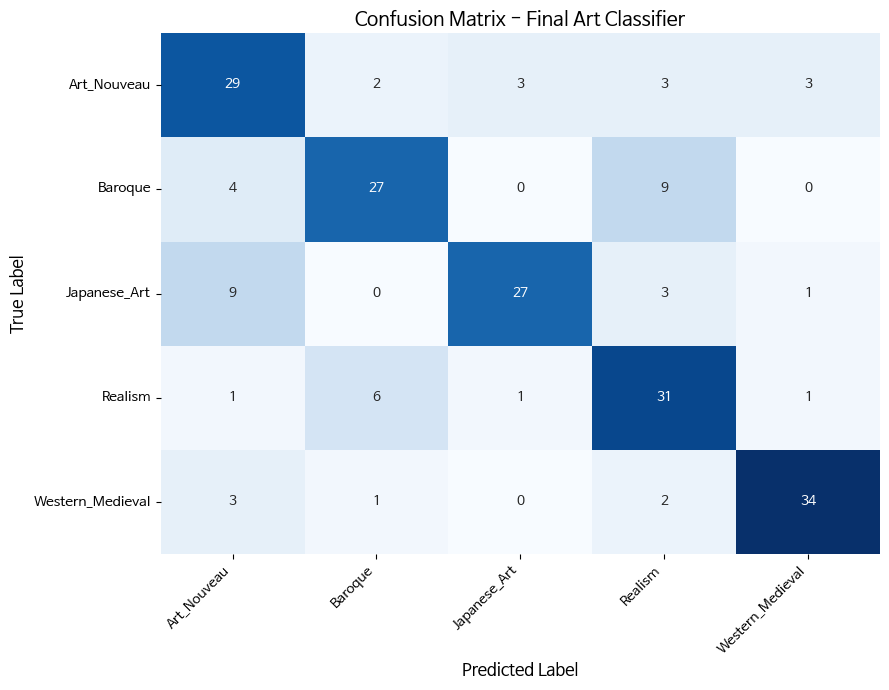

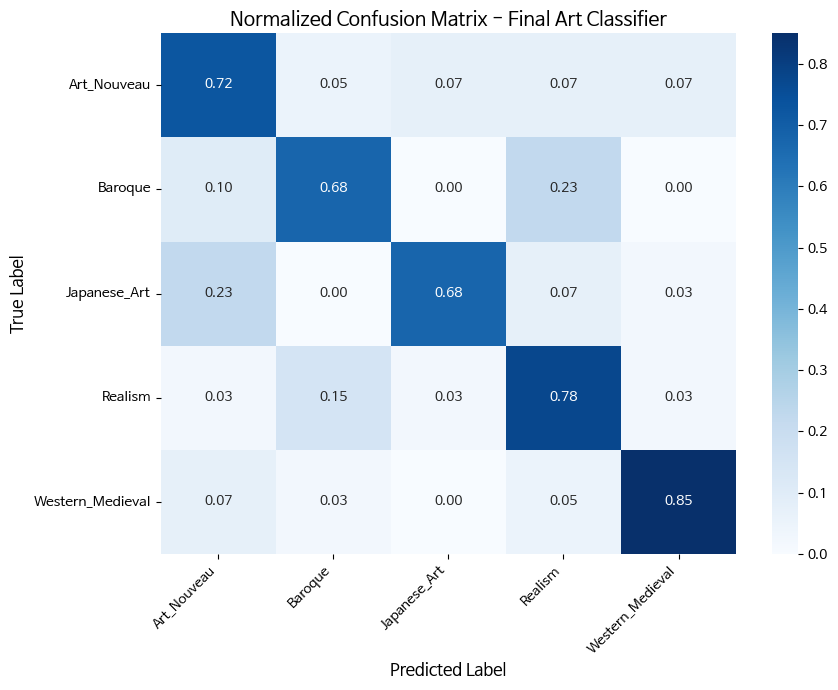

In [78]:
# =====================================================================
# 6. Confusion matrix
# =====================================================================
if "y_true" not in globals() or "y_pred" not in globals():
    if "final_model" not in globals():
        final_model = load_final_model_for_analysis()
    y_true, y_pred, y_prob = predict_validation_dataset(final_model, val_ds)

class_names = ensure_class_names() if "ensure_class_names" in globals() else list(class_names)
labels = np.arange(len(class_names))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("[Confusion Matrix - Validation Data]")
display(cm_df)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Final Art Classifier", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)
cm_normalized_df = pd.DataFrame(cm_normalized, index=class_names, columns=class_names)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_normalized_df, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Normalized Confusion Matrix - Final Art Classifier", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#loss gap 분석

[Loss gap analysis] 07_resnet_dense128_dropout03
Best epoch: 8
Best val_loss: 0.7361
Train loss at best epoch: 0.6419
Loss gap at best epoch: 0.0942


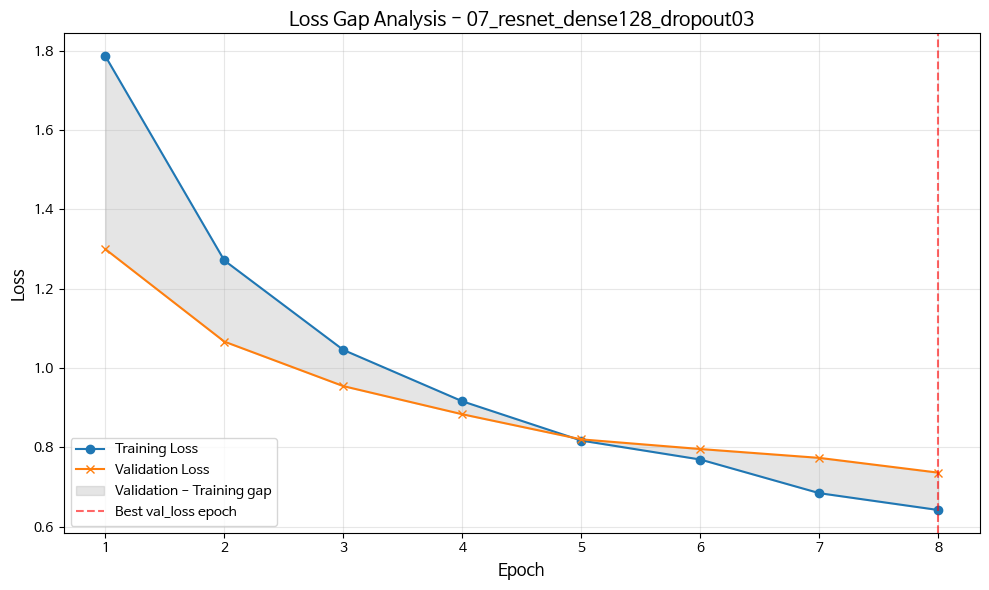

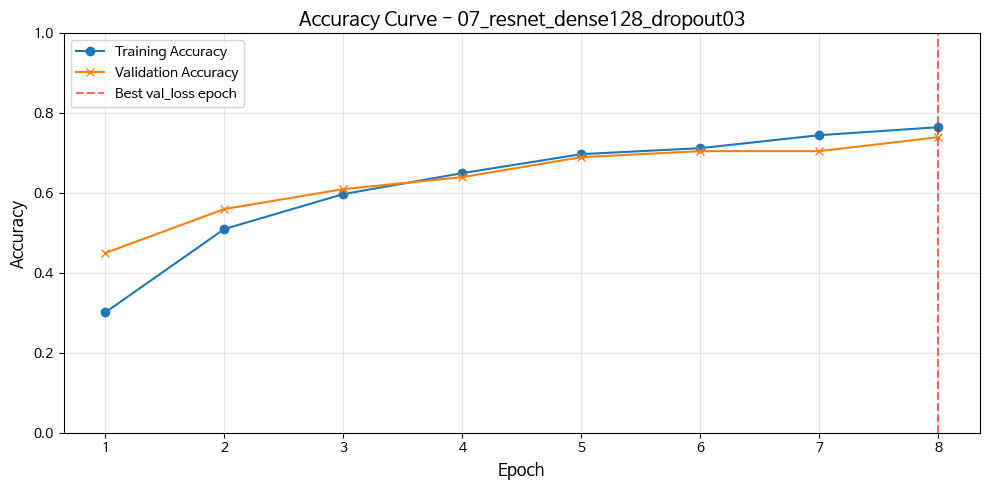

In [79]:
# =====================================================================
# 7. Loss gap analysis
# =====================================================================
def history_to_dataframe(history_obj):
    if hasattr(history_obj, "history"):
        return pd.DataFrame(history_obj.history)
    if isinstance(history_obj, dict):
        return pd.DataFrame(history_obj)
    return pd.DataFrame(history_obj)


def find_best_history_dataframe():
    trial_name = None

    if "mlflow_best_trial" in globals() and isinstance(mlflow_best_trial, dict):
        trial_name = mlflow_best_trial.get("trial_name")
    elif "successful_trials" in globals() and not successful_trials.empty:
        trial_name = successful_trials.iloc[0].get("trial_name")

    if trial_name and "tuned_history_group" in globals() and trial_name in tuned_history_group:
        return history_to_dataframe(tuned_history_group[trial_name]), trial_name

    if trial_name and "MODEL_TUNING_DIR" in globals():
        history_path = Path(MODEL_TUNING_DIR) / f"{trial_name}_history.csv"
        if history_path.exists():
            return pd.read_csv(history_path), trial_name

    if "history_group" in globals() and "ResNet50" in history_group:
        return history_to_dataframe(history_group["ResNet50"]), "ResNet50 baseline"

    if "kfold_histories" in globals() and kfold_histories:
        first_fold_name = sorted(kfold_histories.keys())[0]
        return history_to_dataframe(kfold_histories[first_fold_name]), first_fold_name

    raise RuntimeError(
        "No training history found. Run MLflow tuning, baseline training, or K-fold training first."
    )


history_df, history_label = find_best_history_dataframe()
required_columns = {"loss", "val_loss"}
missing_columns = required_columns - set(history_df.columns)
if missing_columns:
    raise ValueError(f"History is missing required columns: {sorted(missing_columns)}")

train_loss = history_df["loss"].astype(float).to_numpy()
val_loss = history_df["val_loss"].astype(float).to_numpy()
epochs_range = np.arange(1, len(train_loss) + 1)
loss_gap = val_loss - train_loss
best_epoch_idx = int(np.argmin(val_loss))

print(f"[Loss gap analysis] {history_label}")
print(f"Best epoch: {best_epoch_idx + 1}")
print(f"Best val_loss: {val_loss[best_epoch_idx]:.4f}")
print(f"Train loss at best epoch: {train_loss[best_epoch_idx]:.4f}")
print(f"Loss gap at best epoch: {loss_gap[best_epoch_idx]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_loss, label="Training Loss", marker="o")
plt.plot(epochs_range, val_loss, label="Validation Loss", marker="x")
plt.fill_between(
    epochs_range,
    train_loss,
    val_loss,
    color="gray",
    alpha=0.2,
    label="Validation - Training gap",
)
plt.axvline(best_epoch_idx + 1, color="red", linestyle="--", alpha=0.6, label="Best val_loss epoch")
plt.title(f"Loss Gap Analysis - {history_label}", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if {"accuracy", "val_accuracy"}.issubset(history_df.columns):
    train_accuracy = history_df["accuracy"].astype(float).to_numpy()
    val_accuracy = history_df["val_accuracy"].astype(float).to_numpy()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, train_accuracy, label="Training Accuracy", marker="o")
    plt.plot(epochs_range, val_accuracy, label="Validation Accuracy", marker="x")
    plt.axvline(best_epoch_idx + 1, color="red", linestyle="--", alpha=0.6, label="Best val_loss epoch")
    plt.title(f"Accuracy Curve - {history_label}", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
